In [84]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [8]:
data = pd.read_csv('F:\\hack\\features_with_labels_fix.csv')

data.drop("filename",axis=1,inplace=True)

data.head()

,dwt_l1_sub0_energy,dwt_l1_sub0_std,dwt_l1_sub1_energy,dwt_l1_sub1_std,dwt_l1_sub2_energy,dwt_l1_sub2_std,dwt_l2_sub0_energy,dwt_l2_sub0_std,dwt_l2_sub1_energy,dwt_l2_sub1_std,...,hog_30,hog_31,blob_count,blob_area_mean,mser_count,mser_area_mean,houses,roads,ponds,Electric Poles
0,1.293889e+07,94.614494,8849462.489,78.271481,2.823815e+06,44.215037,6.078226e+06,35.728926,5642908.699,34.425040,...,0.139096,0.232650,0,0,312,1427.695513,1,1,0,0
1,9.290762e+06,80.211107,8015501.230,74.478973,1.958869e+06,36.826723,5.043214e+06,32.546262,5651904.143,34.446719,...,0.175904,0.188810,0,0,211,724.331754,1,1,0,0
2,1.510729e+07,102.284391,8765451.690,77.898548,1.937436e+06,36.620339,7.415784e+06,39.461967,6324995.966,36.435911,...,0.182334,0.250316,0,0,308,697.659091,1,1,0,0
3,2.244251e+06,39.418890,2713449.290,43.348637,1.045696e+06,26.908708,1.555733e+06,18.076619,2302818.722,21.989980,...,0.070164,0.098044,0,0,38,765.763158,0,0,1,0
4,1.108905e+06,27.710697,1129969.881,27.952832,4.702590e+05,18.041768,6.939669e+05,12.073120,1285006.298,16.424316,...,0.098516,0.108488,0,0,9,226.888889,0,0,1,0


In [10]:
houses = len(data[data['houses']==1])
roads = len(data[data['roads']==1])
poles = len(data[data['Electric Poles']==1])
ponds = len(data[data['ponds']==1])

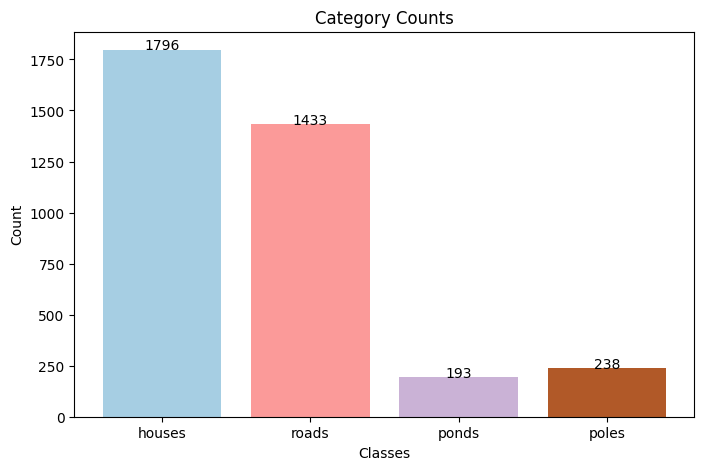

In [ ]:


labels = ['houses', 'roads', 'ponds', 'poles']
values = [houses, roads, ponds, poles]

colors = plt.cm.Paired(np.linspace(0, 1, len(labels)))

plt.figure(figsize=(8,5))
bars = plt.bar(labels, values, color=colors)

plt.title("Category Counts")
plt.xlabel("Classes")
plt.ylabel("Count")

for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        h + 1,
        str(h),
        ha='center',
        fontsize=10
    )

plt.show()

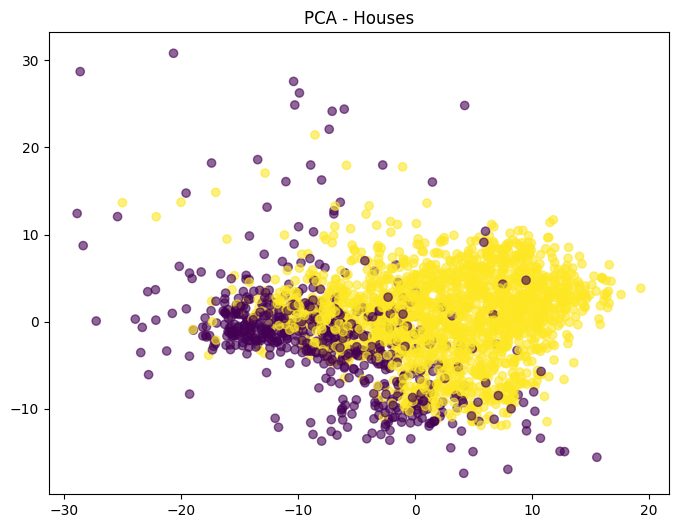

In [ ]:


X = data.drop(columns=['houses','roads','ponds','Electric Poles'])
X = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
Z = pca.fit_transform(X)

plt.figure(figsize=(8,6))
plt.scatter(Z[:,0], Z[:,1], c=data['houses'], alpha=0.6)
plt.title("PCA - Houses")
plt.show()

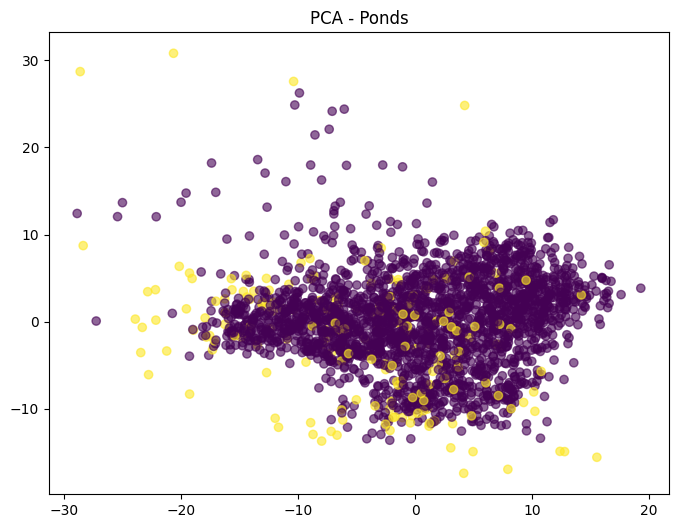

In [ ]:

X = data.drop(columns=['houses','roads','ponds','Electric Poles'])
X = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
Z = pca.fit_transform(X)

plt.figure(figsize=(8,6))
plt.scatter(Z[:,0], Z[:,1], c=data['ponds'], alpha=0.6)
plt.title("PCA - Ponds")
plt.show()

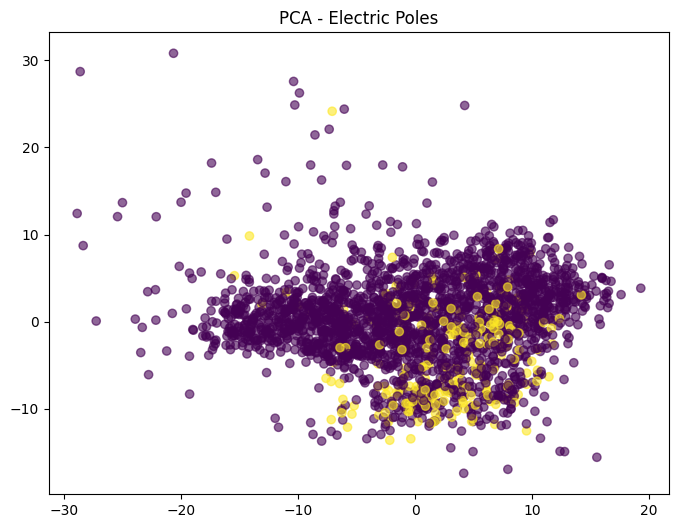

In [ ]:


X = data.drop(columns=['houses','roads','ponds','Electric Poles'])
X = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
Z = pca.fit_transform(X)

plt.figure(figsize=(8,6))
plt.scatter(Z[:,0], Z[:,1], c=data['Electric Poles'], alpha=0.6)
plt.title("PCA - Electric Poles")
plt.show()

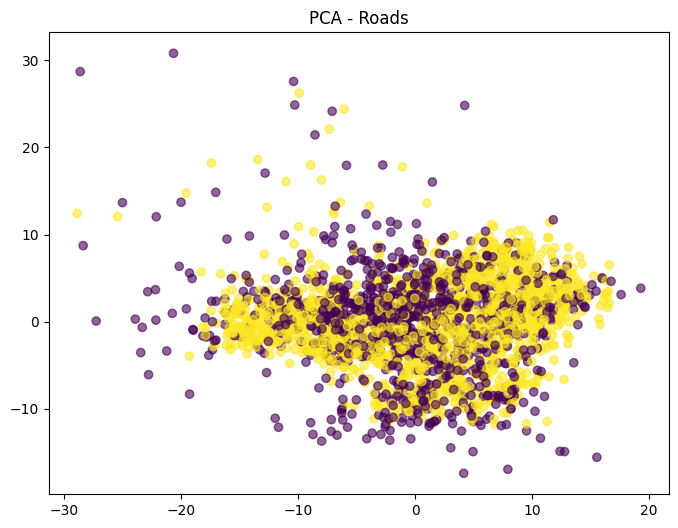

In [ ]:


X = data.drop(columns=['houses','roads','ponds','Electric Poles'])
X = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
Z = pca.fit_transform(X)

plt.figure(figsize=(8,6))
plt.scatter(Z[:,0], Z[:,1], c=data['roads'], alpha=0.6)
plt.title("PCA - Roads")
plt.show()

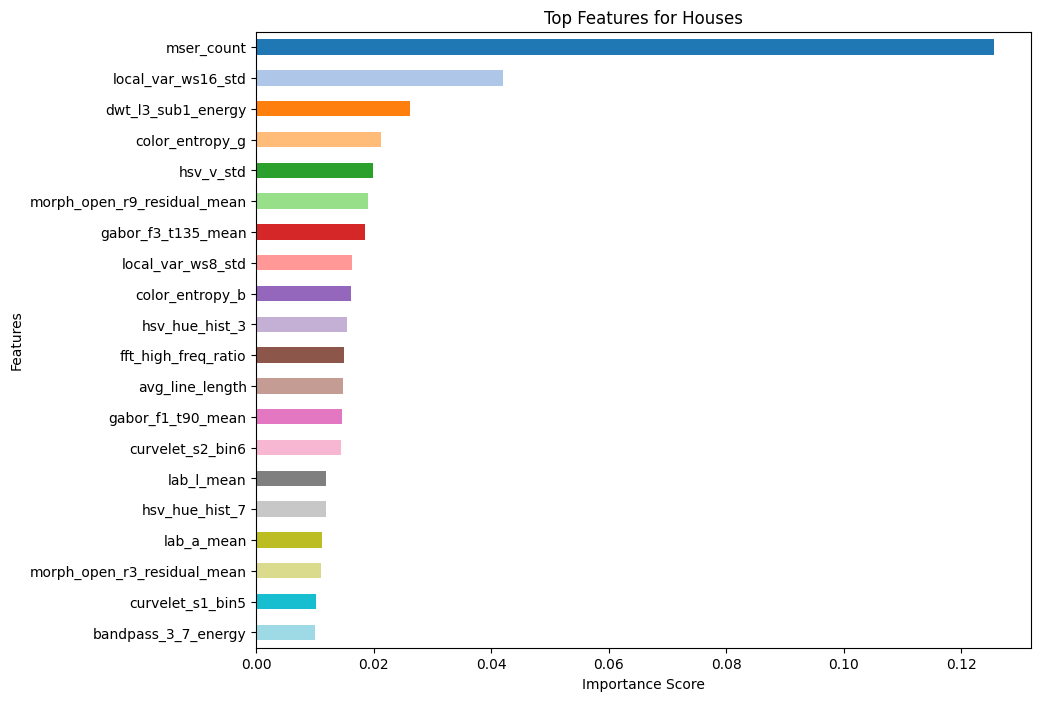

In [81]:
y = data['houses']

rf = XGBClassifier()
rf.fit(X, y)

imp = pd.Series(
    rf.feature_importances_,
    index=data.drop(columns=['houses','roads','ponds','Electric Poles']).columns
)

top20 = imp.nlargest(20)

colors = plt.cm.tab20(np.linspace(0, 1, len(top20)))

top20.plot(
    kind='barh',
    color=colors,
    figsize=(10,8)
)

plt.title("Top Features for Houses")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.gca().invert_yaxis()   
plt.show()

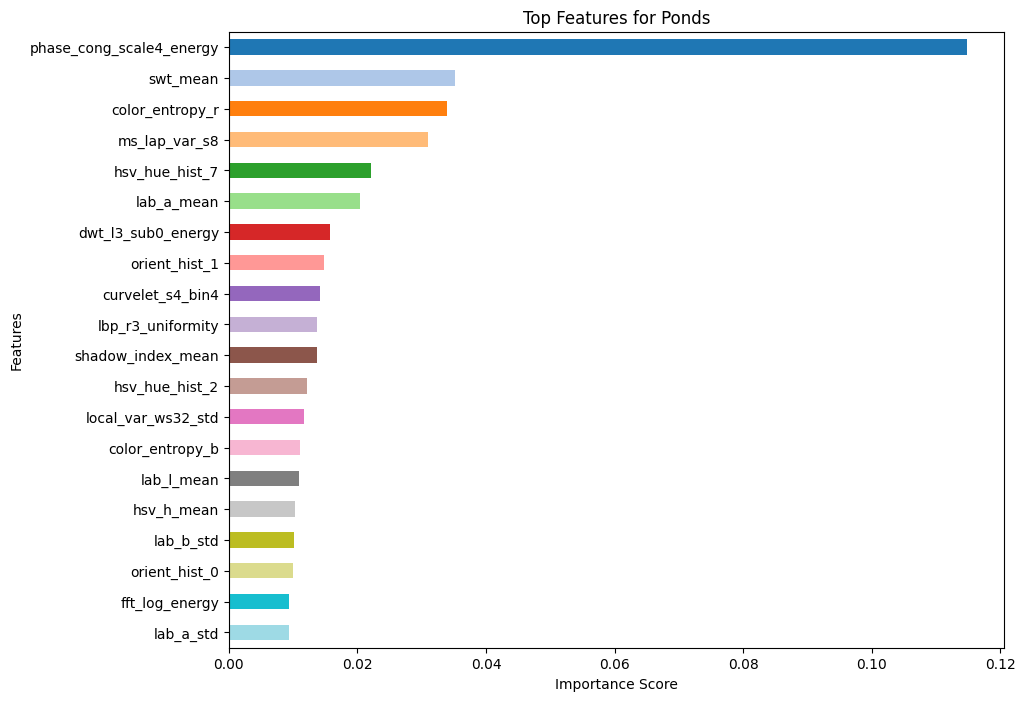

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from xgboost import XGBClassifier

y = data['ponds']

rf = XGBClassifier()
rf.fit(X, y)

imp = pd.Series(
    rf.feature_importances_,
    index=data.drop(columns=['houses','roads','ponds','Electric Poles']).columns
)

top20 = imp.nlargest(20)

colors = plt.cm.tab20(np.linspace(0, 1, len(top20)))

top20.plot(
    kind='barh',
    color=colors,
    figsize=(10,8)
)

plt.title("Top Features for Ponds")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.gca().invert_yaxis()   
plt.show()

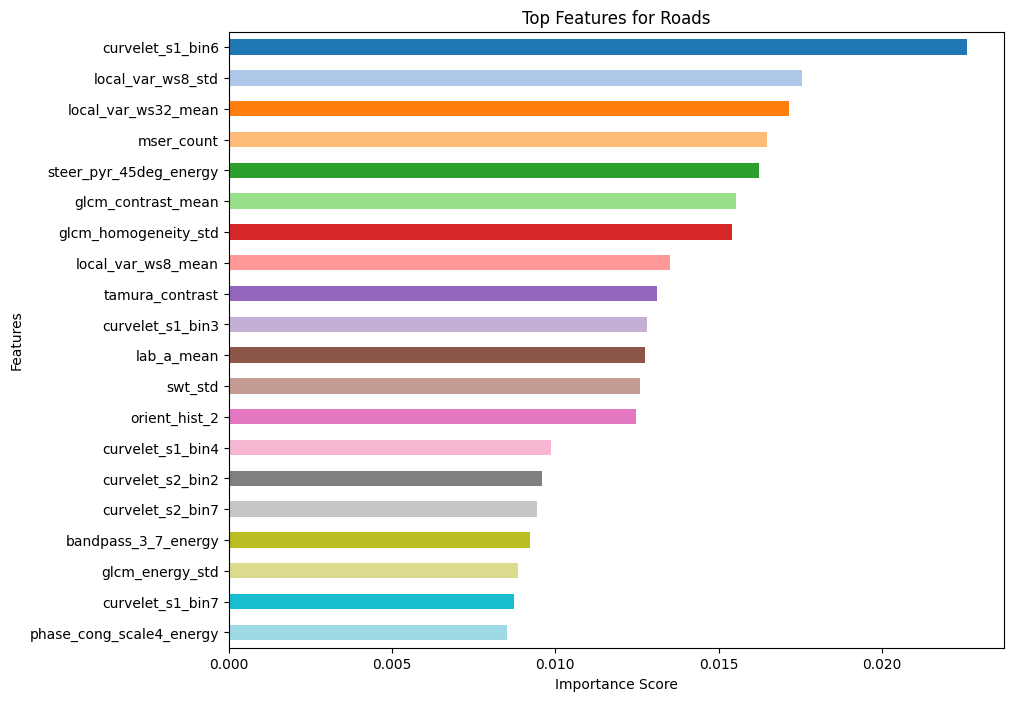

In [82]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from xgboost import XGBClassifier

y = data['roads']

rf = XGBClassifier()
rf.fit(X, y)

imp = pd.Series(
    rf.feature_importances_,
    index=data.drop(columns=['houses','roads','ponds','Electric Poles']).columns
)

top20 = imp.nlargest(20)

colors = plt.cm.tab20(np.linspace(0, 1, len(top20)))

top20.plot(
    kind='barh',
    color=colors,
    figsize=(10,8)
)

plt.title("Top Features for Roads")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.gca().invert_yaxis()   
plt.show()

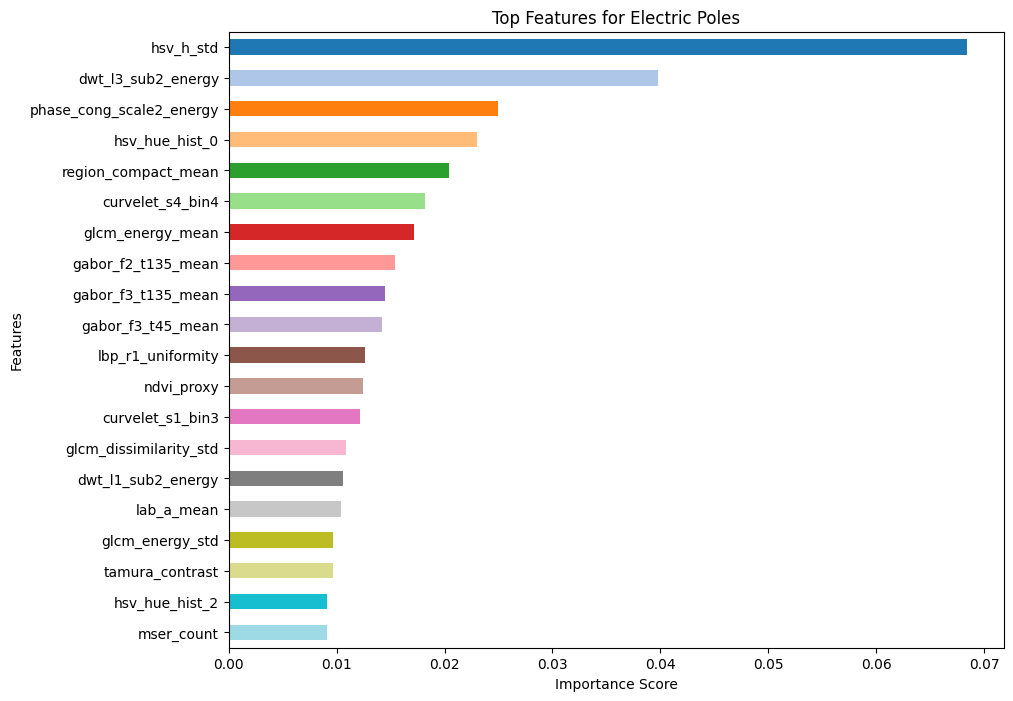

In [83]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from xgboost import XGBClassifier

y = data['Electric Poles']

rf = XGBClassifier()
rf.fit(X, y)

imp = pd.Series(
    rf.feature_importances_,
    index=data.drop(columns=['houses','roads','ponds','Electric Poles']).columns
)

top20 = imp.nlargest(20)

colors = plt.cm.tab20(np.linspace(0, 1, len(top20)))

top20.plot(
    kind='barh',
    color=colors,
    figsize=(10,8)
)

plt.title("Top Features for Electric Poles")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.gca().invert_yaxis()   
plt.show()

c:\Users\Dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


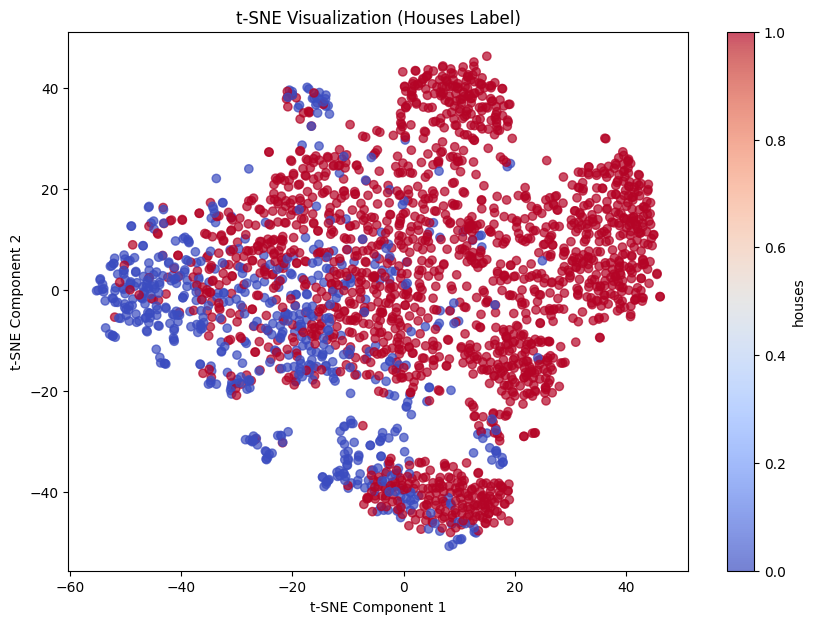

In [ ]:


label_cols = ['houses', 'roads', 'ponds', 'Electric Poles']

X_scaled = StandardScaler().fit_transform(X)

y = data['houses']

# t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=42,
    n_iter=1000
)

X_tsne = tsne.fit_transform(X_scaled)

# Plot
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y,
    cmap='coolwarm',
    alpha=0.7
)

plt.title("t-SNE Visualization (Houses Label)")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.colorbar(scatter, label="houses")
plt.show()

c:\Users\Dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


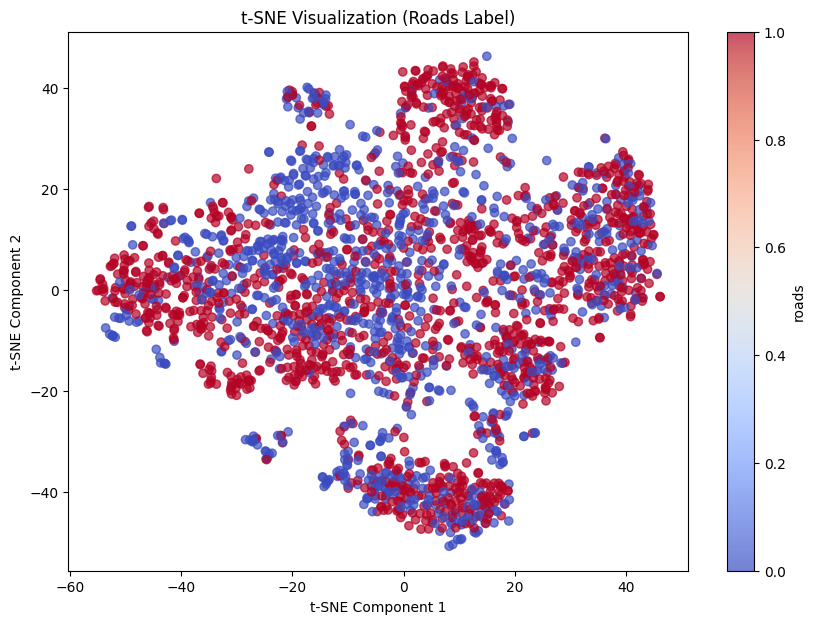

In [63]:

label_cols = ['houses', 'roads', 'ponds', 'Electric Poles']

X_scaled = StandardScaler().fit_transform(X)

y = data['roads']

# t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=42,
    n_iter=1000
)

X_tsne = tsne.fit_transform(X_scaled)

# Plot
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y,
    cmap='coolwarm',
    alpha=0.7
)

plt.title("t-SNE Visualization (Roads Label)")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.colorbar(scatter, label="roads")
plt.show()

c:\Users\Dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


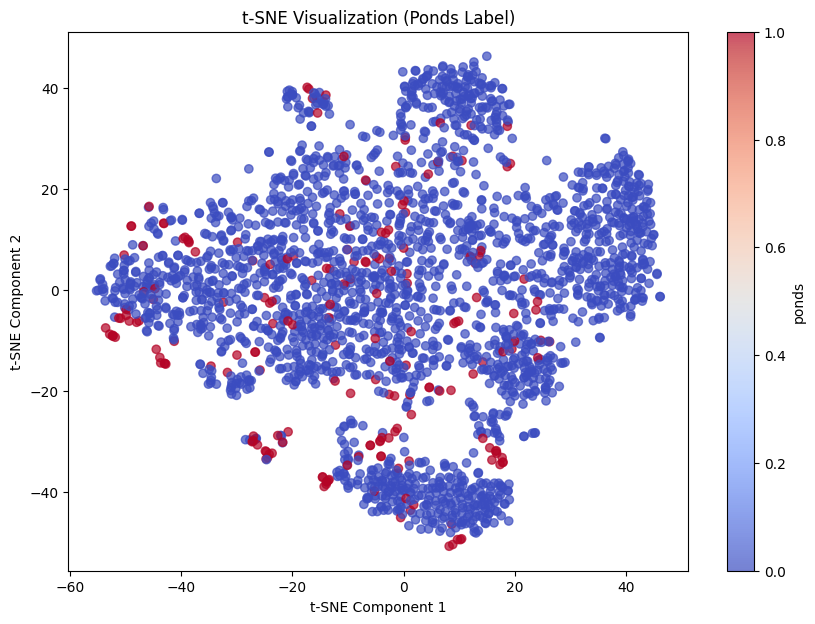

In [64]:

label_cols = ['houses', 'roads', 'ponds', 'Electric Poles']

X_scaled = StandardScaler().fit_transform(X)

y = data['ponds']

# t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=42,
    n_iter=1000
)

X_tsne = tsne.fit_transform(X_scaled)

# Plot
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y,
    cmap='coolwarm',
    alpha=0.7
)

plt.title("t-SNE Visualization (Ponds Label)")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.colorbar(scatter, label="ponds")
plt.show()

c:\Users\Dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


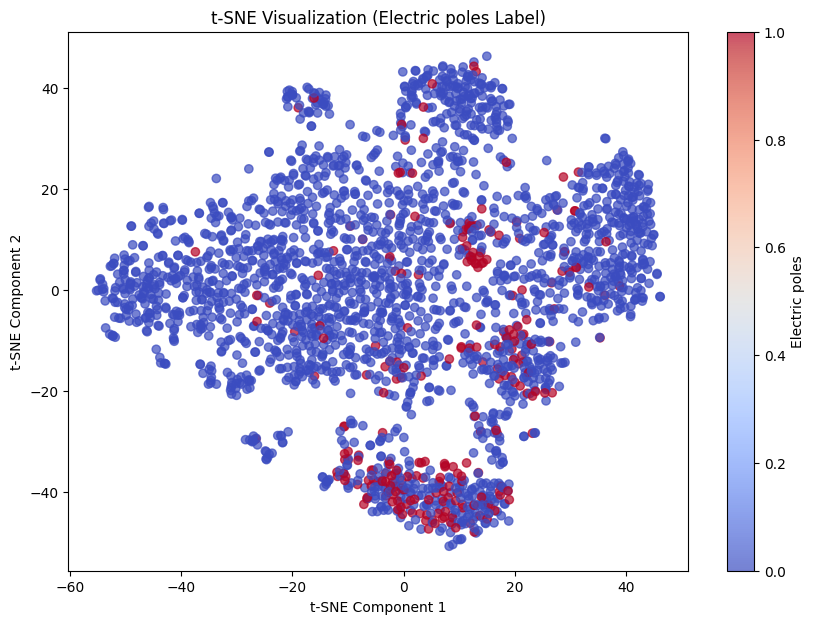

In [ ]:


label_cols = ['houses', 'roads', 'ponds', 'Electric Poles']

X_scaled = StandardScaler().fit_transform(X)

y = data['Electric Poles']

# t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=42,
    n_iter=1000
)

X_tsne = tsne.fit_transform(X_scaled)

# Plot
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y,
    cmap='coolwarm',
    alpha=0.7
)

plt.title("t-SNE Visualization (Electric poles Label)")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.colorbar(scatter, label="Electric poles")
plt.show()

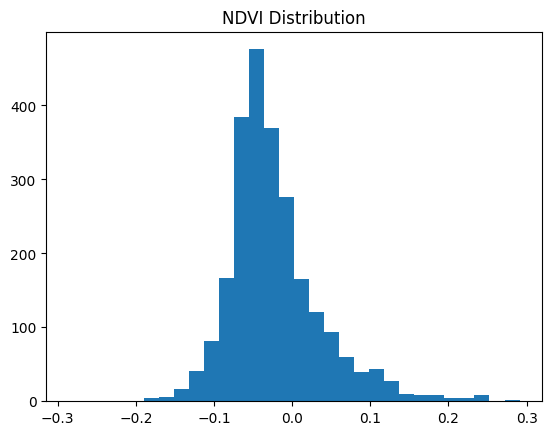

In [47]:
plt.figure()
plt.hist(data['ndvi_proxy'], bins=30)
plt.title("NDVI Distribution")
plt.show()

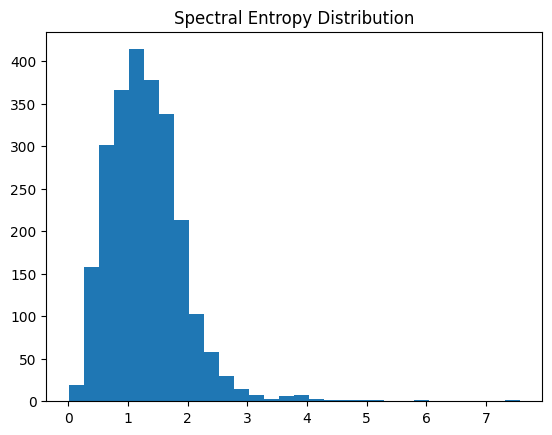

In [49]:
plt.figure()
plt.hist(data['spectral_entropy'], bins=30)
plt.title("Spectral Entropy Distribution")
plt.show()

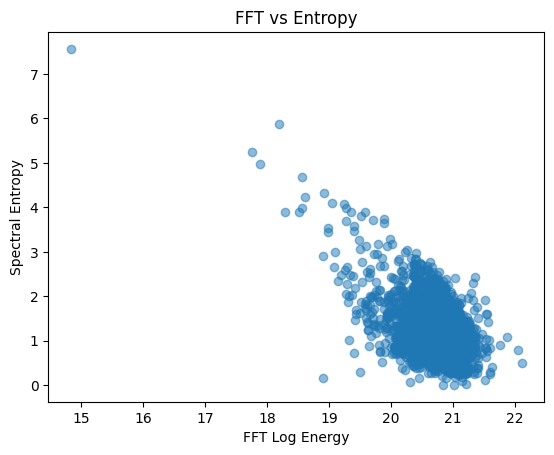

In [62]:
plt.figure()
plt.scatter(data['fft_log_energy'], data['spectral_entropy'], alpha=0.5)
plt.xlabel("FFT Log Energy")
plt.ylabel("Spectral Entropy")
plt.title("FFT vs Entropy")
plt.show()

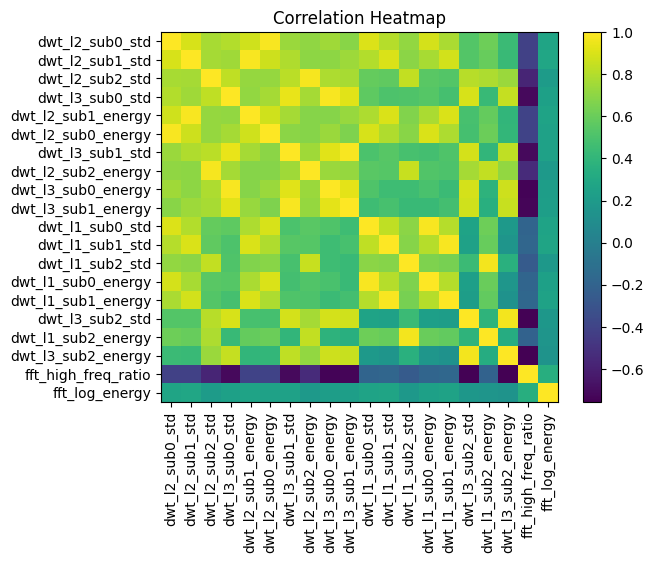

In [ ]:


features = data.columns[:20]
corr = data[features].corr()
top = corr.abs().mean().sort_values(ascending=False).head(20).index
corr_top = data[top].corr()

plt.figure()
plt.imshow(corr_top, aspect='auto')
plt.colorbar()
plt.xticks(range(len(top)), top, rotation=90)
plt.yticks(range(len(top)), top)
plt.title("Correlation Heatmap")
plt.show()

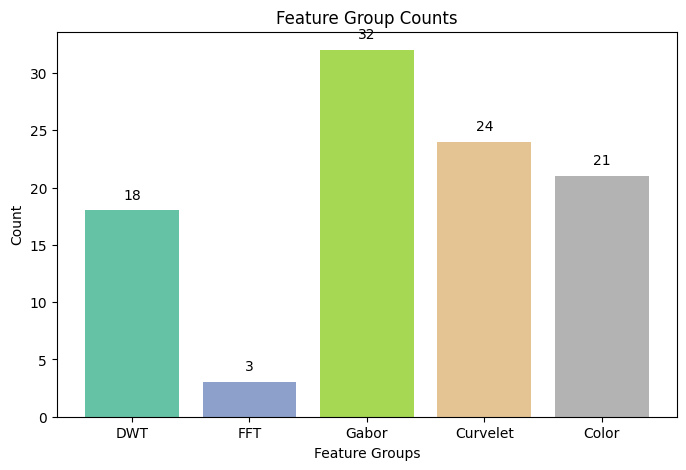

In [85]:


features = data.columns

groups = {
    'DWT': sum(['dwt_' in f for f in features]),
    'FFT': sum(['fft_' in f for f in features]),
    'Gabor': sum(['gabor_' in f for f in features]),
    'Curvelet': sum(['curvelet_' in f for f in features]),
    'Color': sum(['hsv_' in f or 'lab_' in f for f in features])
}

colors = plt.cm.Set2(np.linspace(0, 1, len(groups)))

plt.figure(figsize=(8,5))
plt.bar(groups.keys(), groups.values(), color=colors)

plt.title("Feature Group Counts")
plt.xlabel("Feature Groups")
plt.ylabel("Count")

for i, v in enumerate(groups.values()):
    plt.text(i, v + 1, str(v), ha='center', fontsize=10)

plt.show()

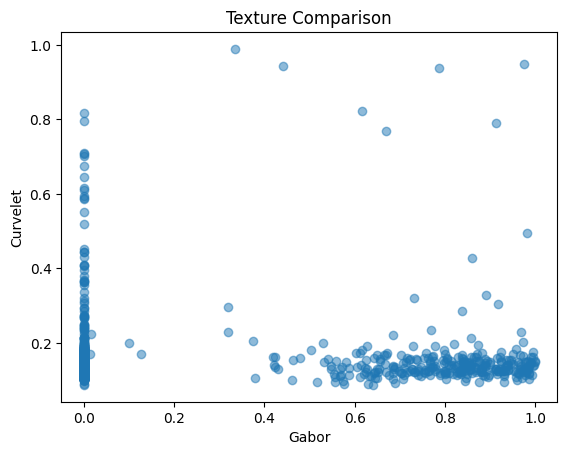

In [57]:
plt.figure()
plt.scatter(data['gabor_f4_t90_std'], data['curvelet_s1_bin4'], alpha=0.5)
plt.xlabel("Gabor")
plt.ylabel("Curvelet")
plt.title("Texture Comparison")
plt.show()

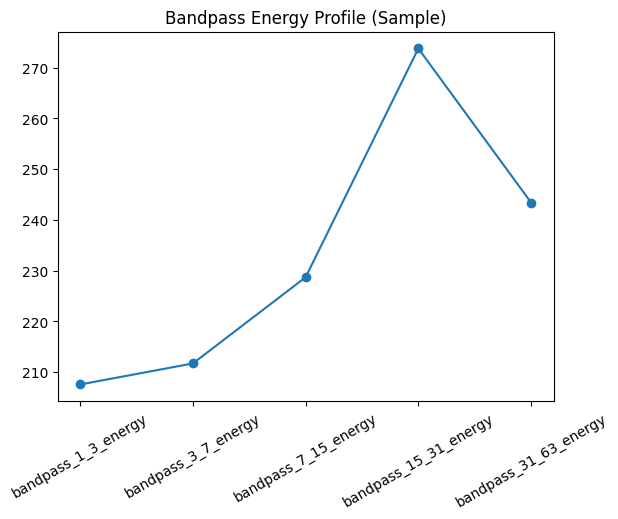

In [58]:
sample = data.iloc[0]

bands = ['bandpass_1_3_energy','bandpass_3_7_energy',
         'bandpass_7_15_energy','bandpass_15_31_energy',
         'bandpass_31_63_energy']

values = [sample[b] for b in bands]

plt.figure()
plt.plot(bands, values, marker='o')
plt.xticks(rotation=30)
plt.title("Bandpass Energy Profile (Sample)")
plt.show()

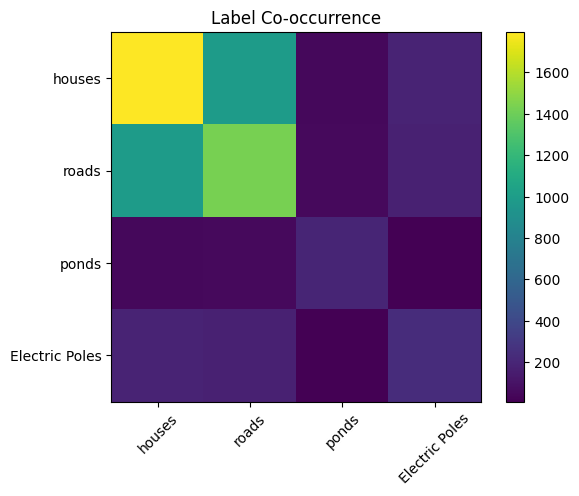

In [ ]:


co_mat = np.dot(data[labels].T, data[labels])

plt.figure()
plt.imshow(co_mat)
plt.colorbar()
plt.xticks(range(len(labels)), labels, rotation=45)
plt.yticks(range(len(labels)), labels)
plt.title("Label Co-occurrence")
plt.show()

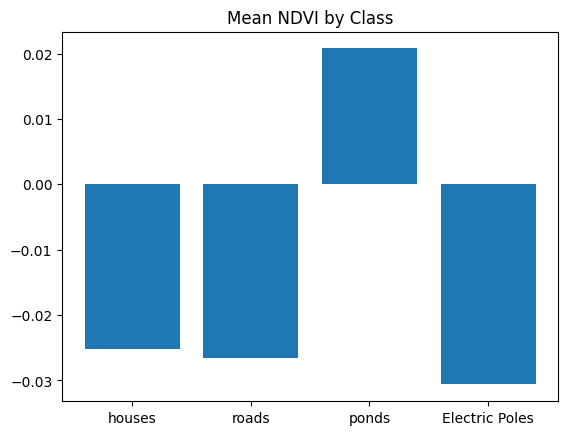

In [68]:
feat = 'ndvi_proxy'

vals = []
for col in labels:
    vals.append(data[data[col]==1][feat].mean())

plt.bar(labels, vals)
plt.title("Mean NDVI by Class")
plt.show()

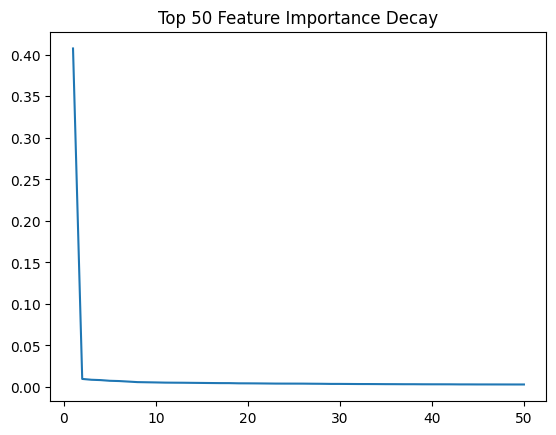

In [ ]:
rf.fit(data[features], data['roads'])
imp = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)

plt.plot(range(1,51), imp.values[:50])
plt.title("Top 50 Feature Importance Decay")
plt.show()